# Multitask Quantile Regression Using RandomForestRegressorMother with Uncertainty Estimation

### What is Multitask Quantile Regression?

In **multitask regression**, we aim to predict multiple target variables (e.g. temperature, humidity, wind, speed) from the same input data. 

**Quantile regression** goes a step further by estimating specific quantiles of the target distribution rather than just the mean. This gives us:

- Point predictions (like the median)
- Possibility to quantify uncertainty (via prediction intervals)

Combining both gives us **multitask quantile regression** - a method which is available via RandomForestRegressorMother. This tutorial aims to demostrate:
- How to train a multitask regression model
- How to estimate predictive uncertainty
- How to interpret and visualize uncertainty in relation to error and data

#### Please only use this method if your targets are correlated and properly scaled to a comparable range! 

In [1]:
import numpy as np
import pandas as pd
import polaris as po
import matplotlib.pyplot as plt
import seaborn as sns
from mother.ml.models import m_randomForest
from scipy.stats import spearmanr
from sklearn import pipeline as sklearn_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.model_selection import GroupKFold

import mother.ml as ml
from mother import feature_generation as fg
from mother.preprocessing import SmilesToMolTransformer, StandardizerTransformer

In [2]:
# Plotting functions used later
def plot_predictions_vs_error(df_pred, y_true, task_name):
    df_pred = df_pred.copy()
    df_pred["abs_error"] = abs(df_pred["mean_predictions"] - y_true)

    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=df_pred, x="total_uncertainty", y="abs_error", alpha=0.4)
    sns.regplot(data=df_pred, x="total_uncertainty", y="abs_error", scatter=False, color="red")
    plt.xlabel("Predicted Uncertainty")
    plt.ylabel("Absolute Error")
    plt.title(f"Uncertainty vs. Error - {task_name}")
    plt.grid()
    plt.tight_layout()
    plt.show()


def plot_predictions_with_uncertainty(df_pred, y_true, task_name):
    plt.figure(figsize=(7, 5))
    plt.errorbar(
        y_true,
        df_pred["mean_predictions"],
        yerr=df_pred["total_uncertainty"],
        fmt="o",
        alpha=0.4,
        ecolor="gray",
        capsize=2,
    )

    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], "r--")
    plt.xlabel("True Values")
    plt.ylabel("Predicted Means")
    plt.title(f"Predictions vs True with Uncertainty - {task_name}")
    plt.grid()
    plt.tight_layout()
    plt.show()


def calibration_plot(df_pred, y_true, task_name, n_bins=10):
    df_pred = df_pred.copy()
    df_pred["abs_error"] = abs(df_pred["mean_predictions"] - y_true)
    df_pred["unc_bin"] = pd.qcut(df_pred["total_uncertainty"], q=n_bins, duplicates="drop")

    grouped = df_pred.groupby("unc_bin").agg(({"total_uncertainty": "mean", "abs_error": "mean"})).reset_index()

    plt.figure(figsize=(7, 5))
    sns.lineplot(data=grouped, x="total_uncertainty", y="abs_error", marker="o")
    plt.xlabel("Predicted Uncertainty (mean per bin)")
    plt.ylabel("Mean Absolute Error")
    plt.title(f"Calibration Curve - {task_name}")
    plt.grid()
    plt.tight_layout()
    plt.show()


def boxplot_error_by_uncertainty_bins(df_pred, y_true, task_name, n_bins=10, show_sample_points=300):
    generator = np.random.default_rng(42)
    df = df_pred.copy()
    df["abs_error"] = (df["mean_predictions"] - np.asarray(y_true)).abs()
    df["unc_bins"] = pd.qcut(df["total_uncertainty"], q=n_bins, labels=False, duplicates="drop")

    grouped = df.groupby("unc_bins", observed=True)
    bin_means = grouped["abs_error"].mean()
    bin_counts = grouped["abs_error"].size()
    bin_medians = grouped["abs_error"].median()

    ordered_bins = sorted(grouped.groups.keys())
    data_per_bin = [df.loc[df["unc_bins"] == b, "abs_error"].to_numpy() for b in ordered_bins]

    plt.figure(figsize=(8, 5))
    plt.boxplot(data_per_bin, positions=np.arange(len(ordered_bins)) + 1, showfliers=False, whis=(5, 95))

    x_positions = np.arange(len(ordered_bins)) + 1
    plt.scatter(x_positions, bin_means.values, s=40, zorder=3)

    if show_sample_points is not None and show_sample_points > 0:
        if len(df) > show_sample_points:
            df_samp = df.sample(show_sample_points, random_state=42)
        else:
            df_samp = df
        n = len(df_samp)
        jitter = generator.uniform(-0.1, 0.1, size=n)
        x_jittered = df_samp["unc_bins"].astype(int).to_numpy() + 1 + jitter
        plt.plot(x_jittered, df_samp["abs_error"].to_numpy(), "o", ms=3, alpha=0.5, linestyle="None", zorder=2)

    plt.xlabel("Predicted total uncertainty(quantile bins)")
    plt.ylabel("Absolute error")
    plt.title(f"Error vs. Predicted Uncertainty (binned) - {task_name}")

    bin_unc_means = grouped["total_uncertainty"].mean().values
    xticklabels = [f"{i + 1}\n(~{u:.2f})" for i, u in enumerate(bin_unc_means)]
    plt.xticks(x_positions, xticklabels)

    plt.text(
        0.02,
        0.98,
        "mean abs. error per bin\nboxes: error distributions (5-95%)",
        transform=plt.gca().transAxes,
        va="top",
    )
    plt.grid(True, axis="y", linestyle="--", alpha=0.35)
    plt.tight_layout()
    plt.show()


def plot_residuals(y_true, y_pred, xlabel):
    plt.figure(figsize=(4, 6))
    plt.scatter(y_true, y_true - y_pred, alpha=0.5)
    plt.axhline(0, color="red", linestyle="--")
    plt.xlabel(xlabel)
    plt.ylabel("Residuals")
    plt.title("Residuals vs. True Experimental Values")
    plt.show()


def evaluate_metrics(y_true, y_pred, task_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    spearman, p_value = spearmanr(y_true, y_pred)

    print(f"Metrics for {task_name}")
    print(f"MAE = {mae:.4f}")
    print(f"MSE = {mse:.4f}")
    print(f"Spearman R = {spearman}")


def joint_quantile_weights(
    y_train: pd.DataFrame,
    bins: int = 10,
    combine: str = "max",
    tau: float = 1.0,
    clip_low: float = 1.0,
    clip_high: float = 99.0,
) -> np.ndarray:
    y_h = y_train["LOG_HLM_CLint"]
    y_r = y_train["LOG_RLM_CLint"]

    # Bin the targets into deciles
    bh = pd.qcut(y_h, q=bins, labels=False, duplicates="drop")
    br = pd.qcut(y_r, q=bins, labels=False, duplicates="drop")

    # Compute inverse-frequency weights
    cnt_h = bh.value_counts().to_dict()
    cnt_r = br.value_counts().to_dict()
    w_h = bh.map(lambda b: 1.0 / cnt_h[b]).astype(float).values
    w_r = bh.map(lambda b: 1.0 / cnt_r[b]).astype(float).values

    # Combine weights accross tasks
    if combine == "max":  # usees maximum weight from either task
        w = np.maximum(w_h, w_r)
    elif combine == "harmonic":  # punishes samples which are frequent in both tasks
        w = 2.0 / (1.0 / np.clip(w_h, 1e-12, None) + 1.0 / np.clip(w_r, 1e-12, None))
    elif combine == "geom":  # softer balancing
        w = np.sqrt(w_h * w_r)
    else:
        raise ValueError("Combine must be one of 'max', 'harmonic', 'geom'.")

    w = w**tau
    lo, hi = np.percentile(w, clip_low), np.percentile(w, clip_high)
    w = np.clip(w, lo, hi)
    w = w / w.mean()
    return w

### Import Data for Modeling

In this tutorial, we download our dataset from **Polaris** benchmarking platform. It provides standardized datasets with molecule structures encoded as SMILES and experimentally determined properties. 

Here, we use the **adme-fang** dataset, which focuses on ADME (Absorption, Distribution, Metabolism and Excretion) properties. Each molecule in this dataset is associated with multiple regression targets such as e.g. solubility, permeability or metabolic stability - making it ideal for **multitask regression modeling**. 

In [3]:
dataset = po.load_dataset("biogen/adme-fang-v1")
dataset.size()

df = dataset.table
df.head()

Output()

[2025-10-21 12:49:27] INFO     The version of Polaris that was used to create the artifact (dev) is ]8;id=638629;file:///workspaces/mother-ml/.venv/lib/python3.11/site-packages/polaris/_artifact.py\_artifact.py]8;;\:]8;id=511027;file:///workspaces/mother-ml/.venv/lib/python3.11/site-packages/polaris/_artifact.py#96\96]8;;\
                               different from the currently installed version of Polaris (0.13.0).                 

                      INFO     To verify the checksum, we need to recompute it. This can be slow    ]8;id=721093;file:///workspaces/mother-ml/.venv/lib/python3.11/site-packages/polaris/mixins/_checksum.py\_checksum.py]8;;\:]8;id=380305;file:///workspaces/mother-ml/.venv/lib/python3.11/site-packages/polaris/mixins/_checksum.py#67\67]8;;\
                               for large datasets.                                                                 

[12:49:27]  Success: Fetching dataset                                                                 ]8;id=956267;file:///workspaces/mother-ml/.venv/lib/python3.11/site-packages/polaris/utils/context.py\context.py]8;;\:]8;id=2849;file:///workspaces/mother-ml/.venv/lib/python3.11/site-packages/polaris/utils/context.py#53\53]8;;\

,UNIQUE_ID,MOL_smiles,SMILES,LOG_HLM_CLint,LOG_RLM_CLint,LOG_MDR1-MDCK_ER,LOG_HPPB,LOG_RPPB,LOG_SOLUBILITY
0,b5e1231aef0080c76b4207ca1355485432877339,Brc1cc2c(cc1Cn1cncn1)OCCCO2,Brc1cc2c(cc1Cn1cncn1)OCCCO2,0.886265,2.357933,-0.247518,NaN,NaN,1.536432
1,0604cf74e44450d5963d169e18854d96c4e5dba8,Brc1ccc(-c2nnc(Cn3cnc4ccccc43)o2)o1,Brc1ccc(-c2nnc(Cn3cnc4ccccc43)o2)o1,0.675687,1.613704,-0.010669,NaN,NaN,1.797475
2,c518badac8533fdb0de4679c17ce4035eab9ac28,Brc1cnc(N2CCCN(c3ccccc3)CC2)nc1,Brc1cnc(N2CCCN(c3ccccc3)CC2)nc1,2.081607,3.753651,NaN,NaN,NaN,NaN
3,9be43035e7b8a5078babf4345584f4dc6dcd1448,Brc1cnc2ccccc2c1,Brc1cnc2ccccc2c1,NaN,NaN,NaN,NaN,NaN,-0.033858
4,57b907f2f455c3ce3ba21114f32f93b301c99a34,Brc1nnc(N2CCC(OC3CCCC3)CC2)s1,Brc1nnc(N2CCC(OC3CCCC3)CC2)s1,1.888410,3.492201,-0.235024,NaN,NaN,NaN


To enhance the interpretation of the results, we will narrow our focus to two pharmacokinetic properties from this dataset:

- **LOG_HLM_CLint**: Human liver microsomal clearance, which measures the metabolic stability of compounds in the liver.
- **LOG_RLM_CLint**: Rat liver microsomal clearance, representing the logarithmic transformation of the rat liver microsomal intrinsic clearance. This property reflects the same concept but is applicable in preclinical rodent models.


In [4]:
df = df[["SMILES", "LOG_HLM_CLint", "LOG_RLM_CLint"]]

### Basic Exploratory Data Analysis 

<Axes: xlabel='LOG_HLM_CLint', ylabel='Count'>

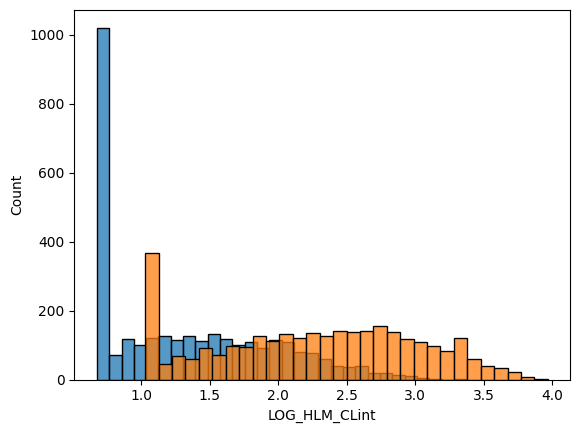

In [5]:
sns.histplot(data=df, x="LOG_HLM_CLint", bins=30)
sns.histplot(data=df, x="LOG_RLM_CLint", bins=30)

- Both distributions are **skewed**, with long tails and dense clusters around small values.
- This imbalance makes predictions harder - the model will be biased towards frequent low-clearance compounds. 

<Axes: xlabel='LOG_HLM_CLint', ylabel='LOG_RLM_CLint'>

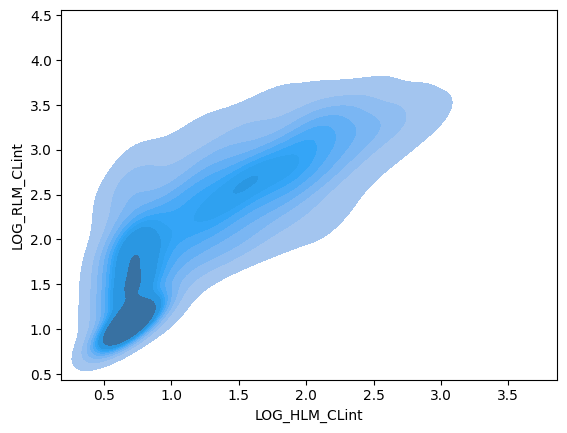

In [6]:
sns.kdeplot(x=df["LOG_HLM_CLint"], y=df["LOG_RLM_CLint"], fill=True)

This plot shows a joint distribution between human (HLM) and rat (RLM) microsomal clearance. 

In [7]:
# Check number of missing values per column in the training data

nan_counts = df.isna().sum()
print("Missing values per column: \n", nan_counts)

# Drop rows with any missing values
df_train = df.dropna().reset_index(drop=True)

df_train.isna().sum()

Missing values per column: 
 SMILES             0
LOG_HLM_CLint    434
LOG_RLM_CLint    467
dtype: int64


SMILES           0
LOG_HLM_CLint    0
LOG_RLM_CLint    0
dtype: int64

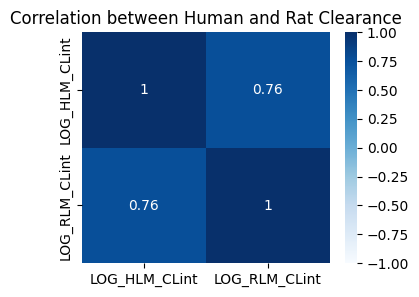

In [8]:
plt.figure(figsize=(4, 3))
sns.heatmap(df[["LOG_HLM_CLint", "LOG_RLM_CLint"]].corr(), annot=True, cmap="Blues", vmin=-1, vmax=1)
plt.title("Correlation between Human and Rat Clearance")
plt.show()

Easy correlation matrix between human and rat clearance. The moderate positive correlation motivates multitask regression - learning from one task can inform the other. 

Be careful if your **targets are not correlated** - such setup is **not suitable for multitask learning**! 

### Data Preprocessing Pipeline 


To prepare our molecular data for modeling, we apply a preprocessing pipeline that performs two key tasks:

- **Standardization of SMILES**: Canonicalizes molecular strings using custom rules.
- **Conversion to Molecule Objects**: Transforms standardized SMILES into RDKit Mol objects, which are required for further featurization.

In [9]:
preprocessor: sklearn_pipeline.Pipeline = sklearn_pipeline.Pipeline(
    [
        (
            "smiles_standardizer",
            StandardizerTransformer(flags=["STANDARDIZE", "NEUTRALIZE", "DESALT"]),
        ),
        ("smiles_to_mol", SmilesToMolTransformer()),
        # Add other column transformations here if needed
    ],
    memory=None,
).set_output(transform="pandas")


structure_data: pd.Series = df_train["SMILES"]
mol_data: pd.DataFrame = preprocessor.fit_transform(structure_data)

[12:49:39] Initializing Normalizer
[12:49:39] Initializing Normalizer
[12:49:39] Initializing MetalDisconnector
[12:49:39] Initializing Normalizer


### Feature Generation

To create a comprehensive feature representation for each molecule, we utilize multiple types of cheminformatics fingerprints and descriptors:

- **MACCS Fingerprints**: Predefined substructure keys.
- **Morgan Fingerprints**: Circular fingerprints that capture local topology.
- **Chemical Descriptors**: Global molecular properties.

We combine these features and transform the RDKit Molecule objects into a consistent feature matrix.

In [10]:
feature_generator = sklearn_pipeline.FeatureUnion(
    transformer_list=[
        ("maccs", fg.MaccsFingerprints()),
        ("morgan", fg.MorganFingerprints()),
        ("desc", fg.ChemicalDescriptors()),
    ],
).set_output(transform="pandas")


features: pd.DataFrame = feature_generator.fit_transform(mol_data["Molecule"])

features.head()

,maccs__maccs_0,maccs__maccs_1,maccs__maccs_2,maccs__maccs_3,maccs__maccs_4,maccs__maccs_5,maccs__maccs_6,maccs__maccs_7,maccs__maccs_8,maccs__maccs_9,...,desc__fr_sulfide,desc__fr_sulfonamd,desc__fr_sulfone,desc__fr_term_acetylene,desc__fr_tetrazole,desc__fr_thiazole,desc__fr_thiocyan,desc__fr_thiophene,desc__fr_unbrch_alkane,desc__fr_urea
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


### Scaffold-Aware Grouping For Cross-Validation

To avoid overestimating model performance due to structurally similar compounds in both training and test sets, we group molecules by Murcko scaffolds and cluster them using HDBSCAN. 

In [11]:
from mother.cv.core import HdbscanGroupingFromMols

groups_engine = HdbscanGroupingFromMols(scaffold="Murcko", min_cluster_size=5)

groups: pd.DataFrame = groups_engine.set_output(transform="pandas").fit_transform(mol_data["Molecule"])

print(f"{groups['hdbscan-group'].nunique()} groups found")

cv = GroupKFold(n_splits=5)

121 groups found


### Train/test split 

Next, we create training and testing subsets, while ensuring that there is no overlap between groups in both sets. 

Instead of splitting on idividual tasks, we use a **multitask target matrix**, to preserve alignment accross multiple endopints.




In [12]:
from sklearn.model_selection import GroupShuffleSplit

clusters = groups["hdbscan-group"].astype(int)
hlm_bins = pd.qcut(df_train["LOG_HLM_CLint"], q=3, labels=False)

joint_groups = clusters.astype(str) + "_" + hlm_bins.astype(str)
gss = GroupShuffleSplit(test_size=0.3, n_splits=1, random_state=42)

train_idx, test_idx = next(gss.split(features, df_train[["LOG_HLM_CLint", "LOG_RLM_CLint"]], groups=joint_groups))
print(f"train_index [:5]: {train_idx[:5]}")
print(f"test_idx [:5]: {test_idx[:5]}")

# Subset the data
X_train, X_test = features.iloc[train_idx], features.iloc[test_idx]
y_train, y_test = (
    df_train[["LOG_HLM_CLint", "LOG_RLM_CLint"]].iloc[train_idx],
    df_train[["LOG_HLM_CLint", "LOG_RLM_CLint"]].iloc[test_idx],
)

# Ensure no group overlap
train_groups = joint_groups.iloc[train_idx].unique()
test_groups = joint_groups.iloc[test_idx].unique()

assert len(set(train_groups) & set(test_groups)) == 0, "Group overlap detected!"

train_index [:5]: [0 2 3 4 5]
test_idx [:5]: [ 1  6 28 35 36]


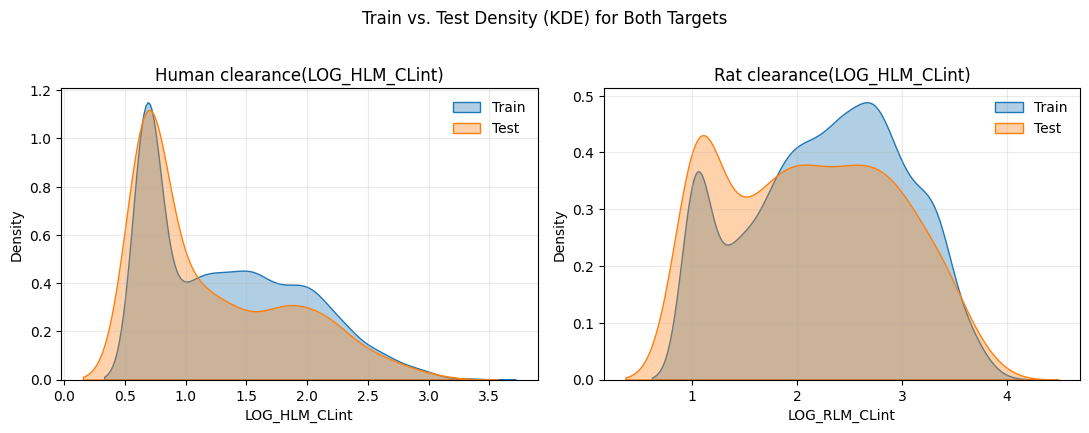

In [13]:
YTr = y_train[["LOG_HLM_CLint", "LOG_RLM_CLint"]].copy()
YTe = y_test[["LOG_HLM_CLint", "LOG_RLM_CLint"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=False, sharey=False)
for col, ax, title in [
    ("LOG_HLM_CLint", axes[0], "Human clearance(LOG_HLM_CLint)"),
    ("LOG_RLM_CLint", axes[1], "Rat clearance(LOG_HLM_CLint)"),
]:
    sns.kdeplot(
        data=YTr, x=col, ax=ax, fill=True, alpha=0.35, linewidth=1, bw_adjust=0.9, common_norm=False, label="Train"
    )
    sns.kdeplot(
        data=YTe, x=col, ax=ax, fill=True, alpha=0.35, linewidth=1, bw_adjust=0.9, common_norm=False, label="Test"
    )

    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.25)
plt.suptitle("Train vs. Test Density (KDE) for Both Targets", y=1.02)
plt.tight_layout()

### Train a Multitask Model 

This step aims to constrict a pipeline for multitask regression model training using RandomForestRegressorMother in a way that it supports both the target prediction and uncertainty estimation via quantile regression. 

**List of quantiles** used for the interquantile range calculation has to be specified **only at prediction step**! 

In [14]:
model_uncertainty = ml.PipelineWithHyperparameterRooting(
    [
        (
            "ml_model",
            m_randomForest.RandomForestRegressorMother(
                n_estimators=1000, max_features="sqrt", criterion="friedman_mse", bootstrap=True, max_samples=0.8
            ),
        ),
    ]
)

# fit the model to the training data
model_uncertainty.fit(X_train, y_train)

PipelineWithHyperparameterRooting(steps=[('ml_model',
                                          RandomForestRegressorMother(bootstrap=True,
                                                                      criterion='friedman_mse',
                                                                      max_features='sqrt',
                                                                      max_samples=0.8,
                                                                      n_estimators=1000))])

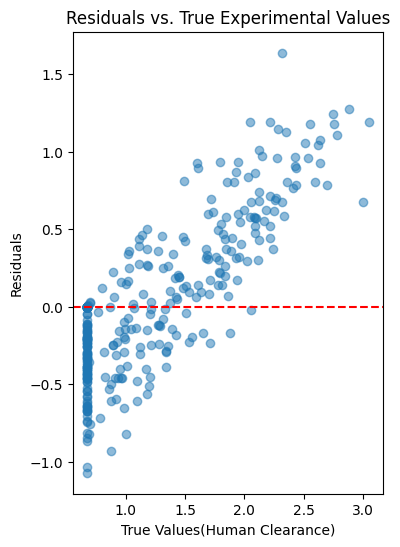

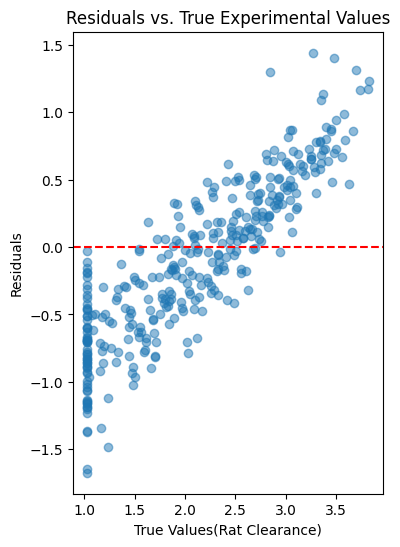

In [15]:
# predict and estimate the uncertainty for test data
df_res, quantiles = model_uncertainty.predict_uncertainty(
    X=X_test, quantiles=[0.10, 0.25, 0.5, 0.75, 0.90], return_quantiles=True
)

plot_residuals(
    y_true=y_test["LOG_HLM_CLint"], y_pred=df_res["target_0"]["mean_predictions"], xlabel="True Values(Human Clearance)"
)
plot_residuals(y_test["LOG_RLM_CLint"], df_res["target_1"]["mean_predictions"], xlabel="True Values(Rat Clearance)")

#### Residual Analysis for Multitask Regression

##### Residuals vs. True Experimental Values (Human Clearance)
This plot shows the residuals (prediction error) against the true human clearance values. The horizontal red dashed line at zero represents perfect prediction. We can see a clear spread of residuals with a tendency to under-predict at higher clearance values (positive residuals). This suggests **systematic bias**, the model struggles with compounds showing very high intrinsic clearance. 

##### Residuals vs. True Experimental Values (Rat Clearance)
For rat clearance, residuals exhibit a similar pattern: predictions are tighter at lower clearance values, where more data pojnts are concentrated. At higher clearance values, residuals become larger and more variable, reflecting limited data coverage and high model uncertainty. 

In [16]:
# We'll compute standard regression metrics

task_1 = "Log-transformed human liver microsomal intrinsic clearance"
task_2 = "Log-transformed rat liver microsomal intrinsic clearance"
evaluate_metrics(
    y_test["LOG_HLM_CLint"],
    df_res["target_0"]["mean_predictions"],
    task_name=task_1,
)
evaluate_metrics(
    y_test["LOG_RLM_CLint"],
    df_res["target_1"]["mean_predictions"],
    task_name="Log-transformed rat liver microsomal intrinsic clearance",
)

Metrics for Log-transformed human liver microsomal intrinsic clearance
MAE = 0.3578
MSE = 0.2305
Spearman R = 0.664093602686287
Metrics for Log-transformed rat liver microsomal intrinsic clearance
MAE = 0.4952
MSE = 0.3608
Spearman R = 0.7094548892226467


### Uncertainty Quantification

A key advantage of quantile forests is their ability to produce prediction intervals. We will now evaluate whether uncertainty estimates align with true prediction errors. 

#### Plot 1: Predictions vs True with Interval Bars

Each point is a compound, vertical bars represent prediction intervals. The red diagonal line is the ideal y=x line. This helps to visualize how uncertainty varies accross the predictions range. Wider bars indicate greater model uncertainty for a given sample. Here, intervals are often large occasionaly asymmetric, suggesting the model is moderately aware of uncertainty but lachs sharp confidence. 

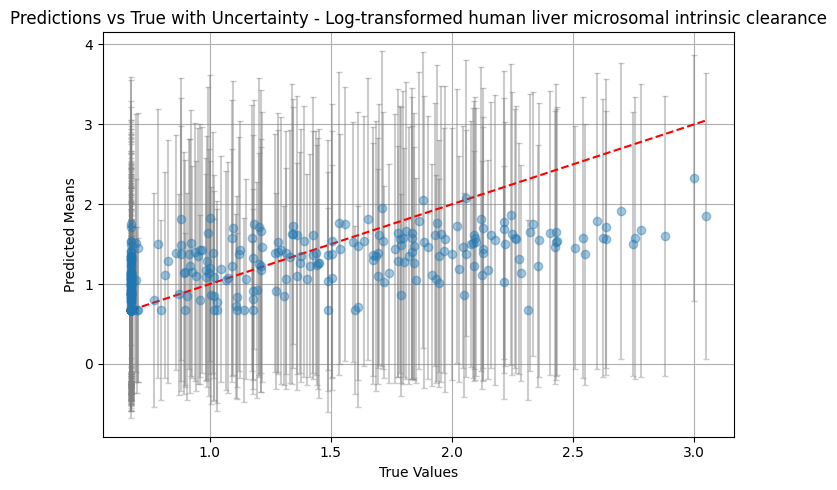

In [17]:
plot_predictions_with_uncertainty(df_res["target_0"], y_test["LOG_HLM_CLint"], task_name=task_1)

#### Plot 2: Error vs. Predicted Ucertainty(binned)

Boxplot of absolute errors accross uncertainty bins, higher uncertainty should have higher errors. We observe a general trend upwards, but with substantial overlap, suggesting only moderate calibration.

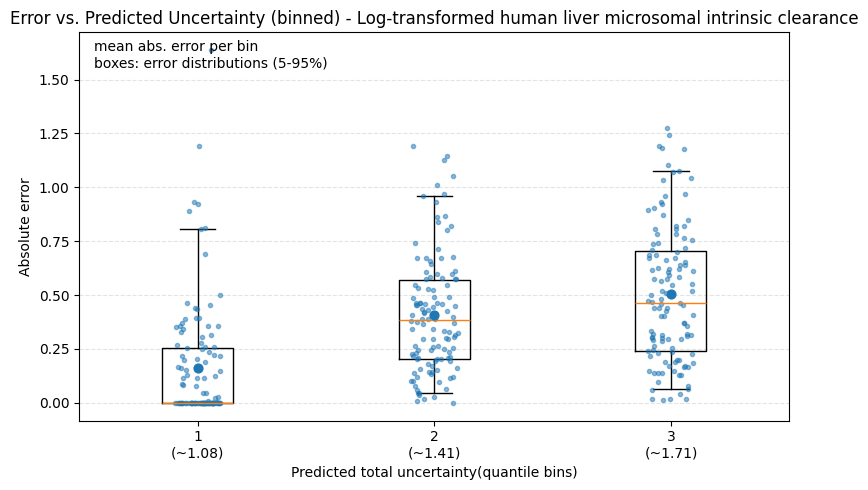

In [18]:
df_pred = df_res["target_0"]
boxplot_error_by_uncertainty_bins(
    df_pred=df_pred,
    y_true=y_test["LOG_HLM_CLint"].values,
    task_name=task_1,
    n_bins=3,
    show_sample_points=400,
)

#### Plot 3: Scatter of Uncertainty vs. Error

Scatter plot of predicted uncertainty vs absolute error. The red line indicates the trend. A positive correlation is visible, confirming that model captures uncertainty in predictions for this target to some extent, though not perfectly. 

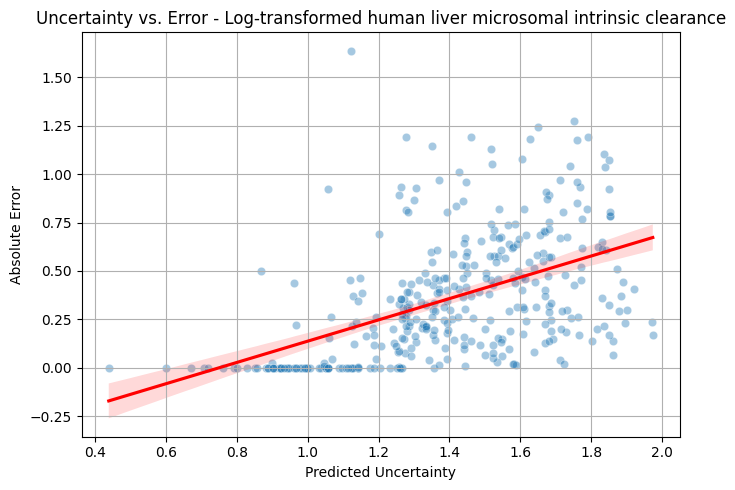

In [19]:
plot_predictions_vs_error(df_res["target_0"], y_test["LOG_HLM_CLint"], task_name=task_1)

This is an example of a calibration-style diagnostic plot for uncertainty estimation. By using this we're trying to answer the question 

*"Do points with higher predicted uncertainty tend to have higher actual error?"*

In general, if uncertainty model works well one should be able to see an upward trend (the red line should slope upward). In our case, the red line trends upwards, suggesting some correlations. The spread, however is wide - meaning predictions with **low uncertainty** still sometimes result in **high error**. 

In addition to this plot, we can quantify correlation between uncertainty and error using **Spearman Correlation Coefficient**. 

In [20]:
from scipy.stats import spearmanr, chatterjeexi

spearman_corr, _ = spearmanr(
    df_res["target_0"]["total_uncertainty"], abs(y_test["LOG_HLM_CLint"] - df_res["target_0"]["mean_predictions"])
)


print(f"Spearman Rank correlation coefficient: {spearman_corr}")

Spearman Rank correlation coefficient: 0.5669508606629576


A Spearman correlation is moderate - suggesting that the model captures uncertainty to some extent, but it is far from ideal. 

#### Plot 4: Calibration Curve 

Finally, let's look at the calibration curve drawn for one of the considered targets. It shows whether the higher uncertainty bins also have higher average error. In general, a well-calibrated curve should show a monotonic increase. 

/tmp/ipykernel_23413/2563467211.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_pred.groupby("unc_bin").agg(({"total_uncertainty": "mean", "abs_error": "mean"})).reset_index()


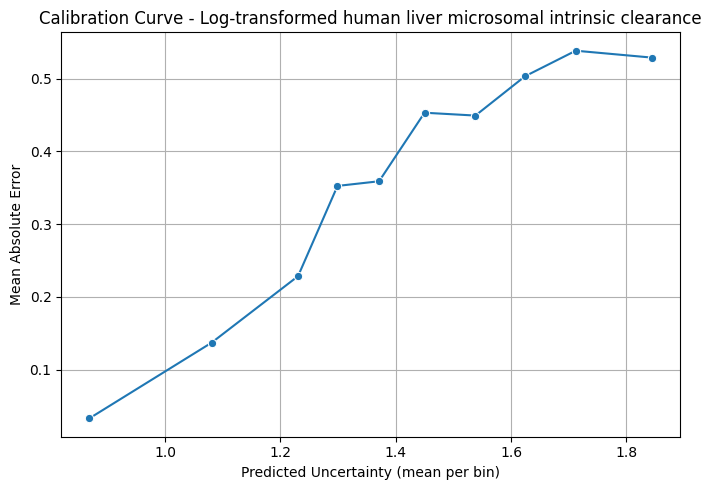

In [21]:
calibration_plot(df_res["target_0"], y_test["LOG_HLM_CLint"], task_name=task_1)

It shows mean absolute error per uncertainty bin. Our curve lies above the diagonal, meaning the model is slightly under-confident (intervals too wide).

#### Plot 5: Prediction Interval Coverage (Calibration Check)

In its default settings, RandomForestRegressorMother uses [0.25, 0.5, 0.75] percentiles, which means that it constructs 50% confidence interval, which should ideally contain ~ 50% of true values if the model is well calibrated. However, in our case, we specified two additional quantiles [0.10, 0.90] at the predictions step.

In [22]:
q10 = quantiles["target_0"]["quantile_0.1"].values
q90 = quantiles["target_0"]["quantile_0.9"].values
y = y_test["LOG_HLM_CLint"].values

coverage = ((y >= q10) & (y <= q90)).mean()
print(f"Prediction interval coverage (80% interval): {coverage}")

Prediction interval coverage (80% interval): 0.9323943661971831


Coverage analysis of the 80% prediction interval shows ~94% empirical coverage. Since this is above 80%, the model is conservative, producing intervals wider than necessary. While this reduces risk of overconfident predictions, it also suggests that the uncertainty quantification could be sharpened, for example by applying post-hoc calibration methods such as conformal prediction or isotonic regression.

#### Plot 6: Predictions vs. True Experimental Values with Color-Coded Uncertainty

Predicted means are plotted against true experimental values for human microsomal clearance. The diagnonal dashed red line represents perfect prediction. Each point is colored by the model's predicted uncertainty, with purple indicating low uncertainty values and yellow high uncertainty. 

Text(0.5, 1.0, 'Predictions vs True (Uncertainty encoded as color)')

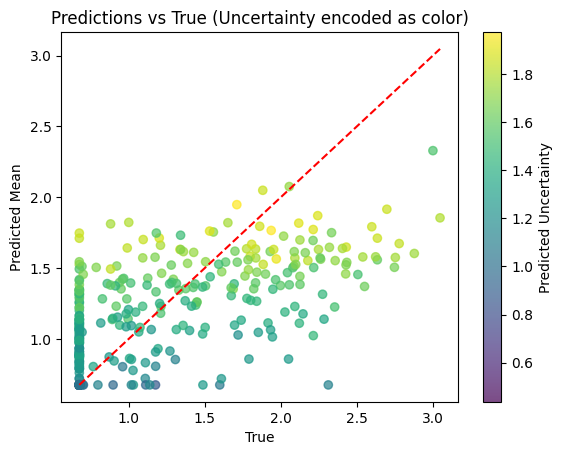

In [23]:
plt.scatter(
    y_test["LOG_HLM_CLint"].values,
    df_pred["mean_predictions"],
    c=df_pred["total_uncertainty"],
    cmap="viridis",
    alpha=0.7,
)
plt.plot(
    [y_test["LOG_HLM_CLint"].values.min(), y_test["LOG_HLM_CLint"].values.max()],
    [y_test["LOG_HLM_CLint"].values.min(), y_test["LOG_HLM_CLint"].values.max()],
    "r--",
)
plt.colorbar(label="Predicted Uncertainty")
plt.xlabel("True")
plt.ylabel("Predicted Mean")
plt.title("Predictions vs True (Uncertainty encoded as color)")

While some correlation is observed - high error regions often display high uncertainty - many low-error predictions are still assigned high uncertainty. This explains why the coverage analysis showed slightly high over-wide prediction intervals.

## Bonus Section: Reducing Target Bias with Sample weigting

Our ealier analysis (see histograms and residual plots) showed that the model **tends to underpredict high-clearance compounds**(residual plots). This happens because the dataset is skewed - most compounds cluster in low-clearance regions. To mitigate this, we can reweight the training data so that rate high-clearance samples have more influence during training.

In [24]:
# Get weights using helper function joint_quantile_weights()
w_joint = joint_quantile_weights(y_train, bins=10, combine="max", tau=1.0)
print("weights stats:", np.min(w_joint), np.mean(w_joint), np.max(w_joint))

weights stats: 0.5873105406732767 1.0 1.176804391906677


The resulting weight vevtor w_joint can be now passed to the model's .fit() call.

In [25]:
additional_parameters = {"max_features": "sqrt", "criterion": "friedman_mse", "bootstrap": True, "max_samples": 0.8}
model_H = m_randomForest.RandomForestRegressorMother(n_estimators=1000, **additional_parameters)
model_H.fit(X_train, y_train["LOG_HLM_CLint"], sample_weight=w_joint)

model_R = m_randomForest.RandomForestRegressorMother(n_estimators=1000, **additional_parameters)
model_R.fit(X_train, y_train["LOG_RLM_CLint"], sample_weight=w_joint)

RandomForestRegressorMother(bootstrap=True, criterion='friedman_mse',
                            max_features='sqrt', max_samples=0.8,
                            n_estimators=1000)

In [26]:
df_H = model_H.predict_uncertainty(X=X_test, quantiles=[0.10, 0.25, 0.5, 0.75, 0.90])
df_R = model_R.predict_uncertainty(X=X_test, quantiles=[0.10, 0.25, 0.5, 0.75, 0.90])

In [27]:
# We'll compute standard regression metrics
evaluate_metrics(
    y_test["LOG_HLM_CLint"],
    df_H["mean_predictions"],
    task_name=task_1,
)
evaluate_metrics(
    y_test["LOG_RLM_CLint"],
    df_R["mean_predictions"],
    task_name=task_2,
)

Metrics for Log-transformed human liver microsomal intrinsic clearance
MAE = 0.3617
MSE = 0.2302
Spearman R = 0.6588012151016092
Metrics for Log-transformed rat liver microsomal intrinsic clearance
MAE = 0.4886
MSE = 0.3559
Spearman R = 0.7140402542579515
